# COMP0258 Demo Notebook

This notebook contains our research demo.

- The VAE section focuses on perturbing encoded levels in the latent space and a CMA-ES search demo in latent space. We also add in a demo of a trained agent on an unseen test maze. Since running through iterations of accel is computationally heavy and slow, we demonstrate the parts of the algorithm which we modified. 

- The LLM Section focusses on DAWDHSUIsDKjANSKDjnaszkjdnkaJDNjkasndkjsakjNDKJNaSJK

### Setup & Downloading Files

In [1]:
# ── Colab-only: clone repo, install deps, download assets ──
# Skip this cell when running locally.
#
# Assets are pulled automatically from public Drive assets.zip (gdown):
# https://drive.google.com/file/d/1_gqw6v4cNDxLm1BYmtfz2dLyt3_jG3n9/view?usp=drive_link
#
# Re-download: set env NOTEBOOK_ASSETS_FORCE=1 before running this cell, or locally run:
#   python notebooks/download_notebook_assets.py --force
import os
import subprocess
import sys


def run_stream(cmd):
    """Run a command and stream stdout/stderr live to the cell."""
    print('$', ' '.join(cmd), flush=True)
    proc = subprocess.Popen(
        cmd,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
    )
    assert proc.stdout is not None
    for line in proc.stdout:
        print(line, end='')
    rc = proc.wait()
    if rc != 0:
        raise subprocess.CalledProcessError(rc, cmd)


COLAB = os.path.exists('/content')
REPO = '/content/superintelligence'

if COLAB and not os.path.isdir(REPO):
    run_stream([
        'git',
        'clone',
        '-b',
        'Notebook',
        'https://github.com/khyledhanani/superintelligence.git',
        REPO,
    ])

if COLAB and os.path.isdir(REPO):
    run_stream([
        sys.executable,
        '-m',
        'pip',
        'install',
        '-e',
        f'{REPO}[examples]',
        'matplotlib',
        'plotly',
        'cma',
        'absl-py',
        'PyYAML',
        'gdown',
    ])
    script = os.path.join(REPO, 'notebooks', 'download_notebook_assets.py')
    marker = os.path.join(
        REPO, 'notebooks', 'assets', 'cluttr_vae_aligned_checkpoint_2060000.pkl'
    )
    force = os.environ.get('NOTEBOOK_ASSETS_FORCE', '').lower() in ('1', 'true', 'yes')
    if os.path.isfile(script) and (force or not os.path.isfile(marker)):
        cmd = [sys.executable, '-u', script]
        if force:
            cmd.append('--force')
        run_stream(cmd)
    elif os.path.isfile(marker):
        print('Assets already present; skipping download script.')


In [2]:
import importlib.util
import os
import subprocess
import sys
from pathlib import Path

_nb = globals().get('__vsc_ipynb_file__')
PROJECT_ROOT = Path(_nb).resolve().parent.parent if _nb else Path('/content/superintelligence')
ASSET_DIR = PROJECT_ROOT / 'notebooks' / 'assets'
VAE_CHECKPOINT_PATH = ASSET_DIR / 'cluttr_vae_aligned_checkpoint_2060000.pkl'
TRAINING_STYLE_DATASET_PATH = ASSET_DIR / 'cluttr_envs_20k.npy'
AGENT_CHECKPOINT_DIR = ASSET_DIR / 'models'

os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
if str(PROJECT_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / 'src'))

LATENT_MODE = 'scaled'
PARENT_INDEX = 12
CMA_STEPS = 10
CMA_POPSIZE = 16
ROLLOUT_STEPS = 250
TEST_LEVEL_NAMES = [
    'NarrowBridge', 'ForkDeception', 'PerimeterRun', 'SpiralPocket', 'SymmetricCross',
    'ZigZagTunnel', 'RoomKeyhole', 'DualLoopChoice', 'CentralChoke', 'LongDetour',
    'DeadendFan', 'OpenFieldBarriers', 'ParallelCorridors', 'CornerTrapEscape', 'SnakeSpine',
]

print('PROJECT_ROOT =', PROJECT_ROOT)
print('ASSET_DIR =', ASSET_DIR)
print('VAE_CHECKPOINT_PATH =', VAE_CHECKPOINT_PATH)
print('TRAINING_STYLE_DATASET_PATH =', TRAINING_STYLE_DATASET_PATH)
print('AGENT_CHECKPOINT_DIR =', AGENT_CHECKPOINT_DIR)

if not VAE_CHECKPOINT_PATH.exists() and not os.path.exists('/content'):
    print(
        'VAE checkpoint not found. From the repo root run:\n'
        '  python notebooks/download_notebook_assets.py\n'
        'Public Drive folder: '
        'https://drive.google.com/file/d/1_gqw6v4cNDxLm1BYmtfz2dLyt3_jG3n9/view?usp=drive_link'
    )


PROJECT_ROOT = /Users/khyledhanani/Documents/openend/superintelligence
ASSET_DIR = /Users/khyledhanani/Documents/openend/superintelligence/notebooks/assets
VAE_CHECKPOINT_PATH = /Users/khyledhanani/Documents/openend/superintelligence/notebooks/assets/cluttr_vae_aligned_checkpoint_2060000.pkl
TRAINING_STYLE_DATASET_PATH = /Users/khyledhanani/Documents/openend/superintelligence/notebooks/assets/cluttr_envs_20k.npy
AGENT_CHECKPOINT_DIR = /Users/khyledhanani/Documents/openend/superintelligence/notebooks/assets/models


### VAE Setup & Helper Functions

In [3]:
import pickle
from collections import deque

import absl.logging
import cma
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go
from flax import linen as nn
from matplotlib.colors import ListedColormap

from es.agent_loader import ActorCritic, load_agent, verify_agent_contract
from jaxued.environments.maze import Maze
from jaxued.environments.maze.level import Level, prefabs

absl.logging.set_verbosity('error')

with open(VAE_CHECKPOINT_PATH, 'rb') as f:
    VAE_STATE = pickle.load(f)
VAE_PARAMS = VAE_STATE['params']
print('Loaded VAE step:', VAE_STATE.get('step'))
print('VAE run id:', VAE_STATE.get('run_id'))


class HighwayAligned(nn.Module):
    dim: int = 300

    def setup(self):
        self.dense_g = nn.Dense(self.dim)
        self.dense_fg = nn.Dense(self.dim)
        self.dense_q1 = nn.Dense(self.dim)
        self.dense_q2 = nn.Dense(self.dim)
        self.dense_gate = nn.Dense(self.dim)

    def __call__(self, x):
        g = nn.relu(self.dense_g(x))
        f_g_x = nn.relu(self.dense_fg(g))
        q_x = self.dense_q2(nn.relu(self.dense_q1(x)))
        gate = nn.sigmoid(self.dense_gate(x))
        return gate * f_g_x + (1.0 - gate) * q_x


class CluttrAlignedVAE(nn.Module):
    vocab_size: int = 170
    embed_dim: int = 300
    latent_dim: int = 64
    seq_len: int = 52

    def setup(self):
        self.embed = nn.Embed(self.vocab_size, self.embed_dim)
        self.enc_drop1 = nn.Dropout(rate=0.1)
        self.enc_hw1 = HighwayAligned(self.embed_dim)
        self.enc_hw2 = HighwayAligned(self.embed_dim)
        self.enc_bilstm = nn.Bidirectional(
            nn.RNN(nn.LSTMCell(300)),
            nn.RNN(nn.LSTMCell(300)),
        )
        self.enc_drop2 = nn.Dropout(rate=0.1)
        self.mean_layer = nn.Dense(self.latent_dim)
        self.logvar_layer = nn.Dense(self.latent_dim)
        self.dec_bilstm1 = nn.Bidirectional(
            nn.RNN(nn.LSTMCell(400)),
            nn.RNN(nn.LSTMCell(400)),
        )
        self.dec_bilstm2 = nn.Bidirectional(
            nn.RNN(nn.LSTMCell(400)),
            nn.RNN(nn.LSTMCell(400)),
        )
        self.dec_output = nn.Dense(self.vocab_size)

    def encode(self, x, train: bool = False, return_pretanh: bool = False):
        x = self.embed(x)
        x = self.enc_drop1(x, deterministic=not train)
        x = self.enc_hw1(x)
        x = self.enc_hw2(x)
        outputs = self.enc_bilstm(x)
        outputs = self.enc_drop2(outputs, deterministic=not train)

        fwd_out = outputs[:, :, :300]
        bwd_out = outputs[:, :, 300:]
        h = jnp.concatenate([fwd_out[:, -1, :], bwd_out[:, 0, :]], axis=-1)

        mean_pretanh = self.mean_layer(h)
        mean = jnp.tanh(mean_pretanh) * 6.0
        logvar = jnp.clip(self.logvar_layer(h), -10.0, 4.0)
        if return_pretanh:
            return mean_pretanh, mean, logvar
        return mean, logvar

    def decode(self, z):
        squeeze = False
        if z.ndim == 1:
            z = z[jnp.newaxis, :]
            squeeze = True

        z_seq = jnp.tile(z[:, jnp.newaxis, :], (1, self.seq_len, 1))
        d_out = self.dec_bilstm1(z_seq)
        d_out = self.dec_bilstm2(d_out)
        logits = self.dec_output(d_out)

        if squeeze:
            logits = logits[0]
        return logits


VAE_MODEL = CluttrAlignedVAE()


@jax.jit
def encode_stats_jit(sequences):
    return VAE_MODEL.apply({'params': VAE_PARAMS}, sequences, method=CluttrAlignedVAE.encode, return_pretanh=True)


@jax.jit
def decode_logits_jit(z):
    return VAE_MODEL.apply({'params': VAE_PARAMS}, z, method=CluttrAlignedVAE.decode)


def encode_sequences(sequences, latent_mode=LATENT_MODE):
    sequences = np.asarray(sequences, dtype=np.int32)
    pretanh_mean, scaled_mean, _ = encode_stats_jit(jnp.asarray(sequences))
    if latent_mode == 'raw':
        return np.asarray(pretanh_mean, dtype=np.float32)
    if latent_mode == 'scaled':
        return np.asarray(scaled_mean, dtype=np.float32)
    raise ValueError(f'Unsupported latent mode: {latent_mode}')


def repair_cluttr_sequence(seq):
    seq = np.clip(np.asarray(seq, dtype=np.int32), 0, 169)
    goal = int(np.clip(seq[50], 1, 169))
    agent = int(np.clip(seq[51], 1, 169))
    if goal == agent:
        agent = (agent % 169) + 1
    obstacles = seq[:50].copy()
    obstacles[obstacles == goal] = 0
    obstacles[obstacles == agent] = 0
    obstacles = np.sort(obstacles)
    return np.concatenate([obstacles, np.array([goal, agent], dtype=np.int32)])


def decode_latents(z_batch, repair=True):
    z_batch = np.asarray(z_batch, dtype=np.float32)
    logits = np.asarray(decode_logits_jit(jnp.asarray(z_batch)), dtype=np.float32)
    sequences = np.argmax(logits, axis=-1).astype(np.int32)
    if repair:
        sequences = np.stack([repair_cluttr_sequence(seq) for seq in sequences], axis=0)
    return sequences


def summarize_raw_decoder_health(sequences):
    sequences = np.asarray(sequences, dtype=np.int32)
    goal = sequences[:, 50]
    agent = sequences[:, 51]
    return {
        'invalid_goal_rate': float(np.mean((goal < 1) | (goal > 169))),
        'invalid_agent_rate': float(np.mean((agent < 1) | (agent > 169))),
        'goal_eq_agent_rate': float(np.mean(goal == agent)),
    }


def idx_to_row_col(index, inner_dim=13):
    index = int(index) - 1
    return index // inner_dim, index % inner_dim


def sequence_to_grid(seq, inner_dim=13):
    grid = np.zeros((inner_dim, inner_dim), dtype=np.int32)
    for obs_idx in np.asarray(seq[:50], dtype=np.int32):
        if obs_idx > 0:
            row, col = idx_to_row_col(obs_idx, inner_dim)
            grid[row, col] = 1
    goal_row, goal_col = idx_to_row_col(seq[50], inner_dim)
    agent_row, agent_col = idx_to_row_col(seq[51], inner_dim)
    grid[goal_row, goal_col] = 2
    grid[agent_row, agent_col] = 3
    return grid


def level_to_grid(level):
    wall_map = np.asarray(level.wall_map, dtype=bool)
    grid = np.zeros(wall_map.shape, dtype=np.int32)
    grid[wall_map] = 1
    grid[int(level.goal_pos[1]), int(level.goal_pos[0])] = 2
    grid[int(level.agent_pos[1]), int(level.agent_pos[0])] = 3
    return grid


def bfs_path_length_from_grid(grid):
    walls = grid == 1
    start = tuple(np.argwhere(grid == 3)[0])
    goal = tuple(np.argwhere(grid == 2)[0])
    queue = deque([(start, 0)])
    seen = {start}
    while queue:
        (row, col), dist = queue.popleft()
        if (row, col) == goal:
            return dist
        for drow, dcol in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
            nrow = row + drow
            ncol = col + dcol
            if 0 <= nrow < grid.shape[0] and 0 <= ncol < grid.shape[1]:
                if not walls[nrow, ncol] and (nrow, ncol) not in seen:
                    seen.add((nrow, ncol))
                    queue.append(((nrow, ncol), dist + 1))
    return None


def summarize_sequence(seq):
    seq = np.asarray(seq, dtype=np.int32)
    grid = sequence_to_grid(seq)
    path_length = bfs_path_length_from_grid(grid)
    goal_row, goal_col = idx_to_row_col(seq[50])
    agent_row, agent_col = idx_to_row_col(seq[51])
    return {
        'obstacles': int((seq[:50] > 0).sum()),
        'manhattan': int(abs(goal_row - agent_row) + abs(goal_col - agent_col)),
        'path_length': path_length,
        'solvable': path_length is not None,
    }


def score_sequence(seq):
    summary = summarize_sequence(seq)
    if not summary['solvable']:
        return -10.0 - 0.15 * summary['obstacles']
    return float(summary['path_length'] + 0.35 * summary['obstacles'])


def plot_grid(ax, grid, title=''):
    cmap = ListedColormap(['white', '#111111', '#2ca02c', '#d62728'])
    ax.imshow(grid, cmap=cmap, vmin=0, vmax=3, interpolation='nearest')
    ax.set_xticks(np.arange(-0.5, grid.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, grid.shape[0], 1), minor=True)
    ax.grid(which='minor', color='lightgray', linewidth=0.4)
    ax.tick_params(which='both', bottom=False, left=False, labelbottom=False, labelleft=False)
    ax.set_title(title, fontsize=10)


def plot_sequence_gallery(sequences, titles, ncols=4, figsize_scale=3.2):
    sequences = [np.asarray(seq, dtype=np.int32) for seq in sequences]
    ncols = min(ncols, len(sequences))
    nrows = int(np.ceil(len(sequences) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(figsize_scale * ncols, figsize_scale * nrows))
    axes = np.atleast_1d(axes).ravel()
    for ax, seq, title in zip(axes, sequences, titles):
        plot_grid(ax, sequence_to_grid(seq), title)
    for ax in axes[len(sequences):]:
        ax.axis('off')
    plt.tight_layout()
    return fig


def plot_level_gallery(levels, titles, ncols=4, figsize_scale=3.2):
    ncols = min(ncols, len(levels))
    nrows = int(np.ceil(len(levels) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(figsize_scale * ncols, figsize_scale * nrows))
    axes = np.atleast_1d(axes).ravel()
    for ax, level, title in zip(axes, levels, titles):
        plot_grid(ax, level_to_grid(level), title)
    for ax in axes[len(levels):]:
        ax.axis('off')
    plt.tight_layout()
    return fig


# CLUTTR training-style dataset + latent embeddings + 2D PCA (for perturbation + CMA-ES cells)
training_style_sequences = np.load(TRAINING_STYLE_DATASET_PATH, mmap_mode='r')
if training_style_sequences.ndim != 2 or training_style_sequences.shape[1] != 52:
    raise ValueError(
        f'Expected CLUTTR array (N, 52), got shape {tuple(training_style_sequences.shape)}'
    )

_encode_bs = 256
_parts = []
for _i in range(0, training_style_sequences.shape[0], _encode_bs):
    _chunk = np.asarray(training_style_sequences[_i : _i + _encode_bs], dtype=np.int32)
    _parts.append(encode_sequences(_chunk, latent_mode=LATENT_MODE))
latent_cloud = np.concatenate(_parts, axis=0)

latent_center = latent_cloud.mean(axis=0, keepdims=True)
_z = latent_cloud - latent_center
_, _, _Vt = np.linalg.svd(_z, full_matrices=False)
_Vt2 = _Vt[:2]
PCA_COORDS = _z @ _Vt2.T
PCA_BASIS = _Vt2.T

print(
    'training_style_sequences', tuple(training_style_sequences.shape),
    '| latent_cloud', latent_cloud.shape,
    '| PCA_COORDS', PCA_COORDS.shape,
)



Loaded VAE step: 2060000
VAE run id: 20260309_091933_lr5e-05_lat64_clutr_aligned_rw1000_beta10.0
training_style_sequences (20000, 52) | latent_cloud (20000, 64) | PCA_COORDS (20000, 2)


## VAE Perturbation And Decoding Demo

The cell below is an example of one of the mutation methods we tried. It shows an arbitrarily picked maze (encode sample) as well is its decoded reconstruction from the VAE. We then show mazes which are generated from perturbing the latent representation of that arbitrarily picked maze. The scale of the perturbation is determined by sigma, as you can see the larger the sigma the more different the decoded maze is from its parent.

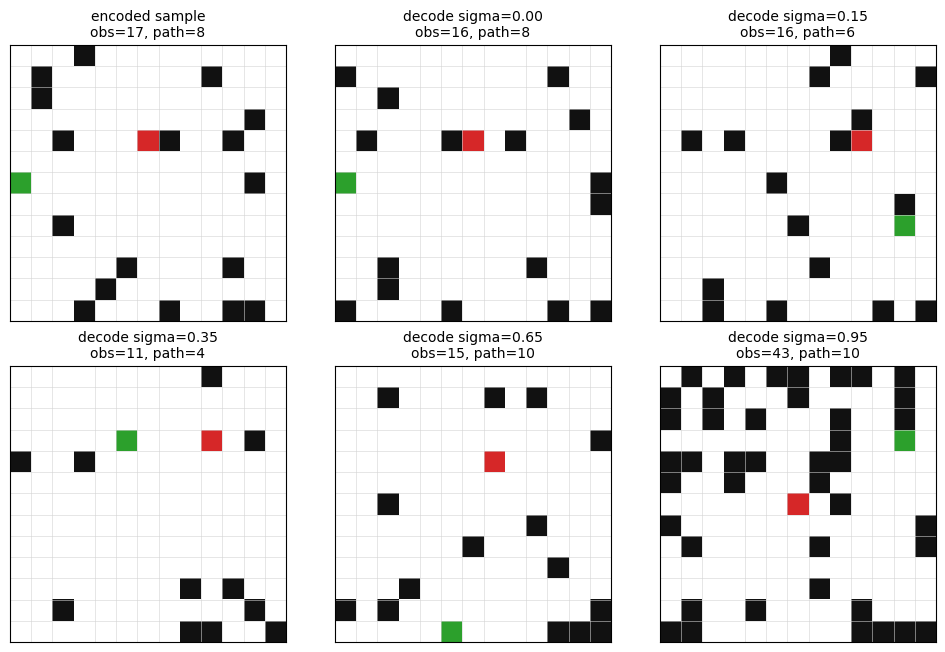

In [4]:
parent_sequence = training_style_sequences[PARENT_INDEX]
parent_latent = latent_cloud[PARENT_INDEX]
noise_rng = np.random.default_rng(7)
sigmas = [0.0, 0.15, 0.35, 0.65, 0.95]
latent_variants = []
for sigma in sigmas:
    if sigma == 0.0:
        latent_variants.append(parent_latent)
    else:
        latent_variants.append(parent_latent + sigma * noise_rng.normal(size=parent_latent.shape).astype(np.float32))
latent_variants = np.stack(latent_variants, axis=0)
decoded_variants = decode_latents(latent_variants, repair=True)

sequences_to_show = [parent_sequence] + list(decoded_variants)
titles = []
original_summary = summarize_sequence(parent_sequence)
titles.append(
    f"encoded sample\nobs={original_summary['obstacles']}, path={original_summary['path_length']}"
)
for sigma, seq in zip(sigmas, decoded_variants):
    summary = summarize_sequence(seq)
    titles.append(f"decode sigma={sigma:.2f}\nobs={summary['obstacles']}, path={summary['path_length']}")

plot_sequence_gallery(sequences_to_show, titles, ncols=3, figsize_scale=3.3)
plt.show()


## CMA-ES Demo In A 2D Latent Plane

The below is an example of a latent space search method we used. In this demo we optimize in the top-2 PCA subspace around the same chosen maze used above. In the paper, we optimize over agent driven fitness, however, for the purposes of simplicity our objective for the optimizer is creating solvable mazes with long path lengths and more walls rather then an agent derived fitness. 

In [5]:
anchor_global = np.asarray((parent_latent[None, :] - latent_center) @ PCA_BASIS, dtype=np.float32)[0]


def plane_to_latent(coords):
    coords = np.atleast_2d(np.asarray(coords, dtype=np.float32))
    return parent_latent[None, :] + coords @ PCA_BASIS.T


es = cma.CMAEvolutionStrategy([0.0, 0.0], 0.65, {'seed': 0, 'popsize': CMA_POPSIZE, 'verbose': -9, 'verb_disp': 0})
history = []
best_score = -np.inf
best_sequence = None
best_global = None

for step_idx in range(CMA_STEPS):
    solutions = np.asarray(es.ask(), dtype=np.float32)
    z_batch = plane_to_latent(solutions)
    decoded_batch = decode_latents(z_batch, repair=True)
    scores = np.asarray([score_sequence(seq) for seq in decoded_batch], dtype=np.float32)
    es.tell(solutions.tolist(), (-scores).tolist())

    population_global = np.asarray((z_batch - latent_center) @ PCA_BASIS, dtype=np.float32)
    mean_coords = np.asarray(es.mean, dtype=np.float32)
    mean_global = anchor_global + mean_coords

    step_best_idx = int(np.argmax(scores))
    if float(scores[step_best_idx]) > best_score:
        best_score = float(scores[step_best_idx])
        best_sequence = decoded_batch[step_best_idx].copy()
        best_global = population_global[step_best_idx].copy()

    history.append({
        'population_global': population_global,
        'scores': scores,
        'mean_global': mean_global,
        'best_global': best_global.copy(),
        'best_score': best_score,
        'step_best_sequence': decoded_batch[step_best_idx].copy(),
    })

best_path = []
frames = []
for step_idx, item in enumerate(history):
    best_path.append(item['best_global'])
    best_path_array = np.asarray(best_path)
    frames.append(
        go.Frame(
            name=str(step_idx),
            data=[
                go.Scatter(
                    x=PCA_COORDS[:, 0],
                    y=PCA_COORDS[:, 1],
                    mode='markers',
                    marker={'size': 5, 'color': 'rgba(120,120,120,0.22)'},
                    name='encoded dataset',
                ),
                go.Scatter(
                    x=item['population_global'][:, 0],
                    y=item['population_global'][:, 1],
                    mode='markers',
                    marker={
                        'size': 11,
                        'color': item['scores'],
                        'colorscale': 'Turbo',
                        'showscale': True,
                        'colorbar': {
                            'title': 'score',
                            'x': 1.02,
                            'xanchor': 'left',
                            'len': 0.62,
                            'thickness': 18,
                            'outlinewidth': 0,
                        },
                    },
                    name='population',
                ),
                go.Scatter(
                    x=best_path_array[:, 0],
                    y=best_path_array[:, 1],
                    mode='lines+markers',
                    marker={'size': 8, 'color': 'crimson'},
                    line={'color': 'crimson', 'width': 2},
                    name='best-so-far',
                ),
                go.Scatter(
                    x=[item['mean_global'][0]],
                    y=[item['mean_global'][1]],
                    mode='markers',
                    marker={'symbol': 'star', 'size': 18, 'color': 'black'},
                    name='search mean',
                ),
            ],
            layout=go.Layout(title=f"CMA-ES latent search iteration {step_idx + 1}/{CMA_STEPS} | best score={item['best_score']:.2f}")
        )
    )

cma_fig = go.Figure(data=frames[0].data, frames=frames)
cma_fig.update_layout(
    width=900,
    height=620,
    margin=dict(l=70, r=120, t=80, b=110),
    xaxis_title='PC1',
    yaxis_title='PC2',
    title='CMA-ES latent search in a 2D PCA plane',
    legend=dict(
        x=0.02,
        y=0.98,
        xanchor='left',
        yanchor='top',
        bgcolor='rgba(255,255,255,0.82)',
        bordercolor='rgba(0,0,0,0.15)',
        borderwidth=1,
    ),
    updatemenus=[{
        'type': 'buttons',
        'buttons': [
            {'label': 'Play', 'method': 'animate', 'args': [None, {'frame': {'duration': 700, 'redraw': True}, 'fromcurrent': True}]},
            {'label': 'Pause', 'method': 'animate', 'args': [[None], {'frame': {'duration': 0, 'redraw': False}, 'mode': 'immediate'}]},
        ],
    }],
    sliders=[{
        'currentvalue': {'prefix': 'Iteration '},
        'steps': [
            {'label': str(i + 1), 'method': 'animate', 'args': [[str(i)], {'frame': {'duration': 0, 'redraw': True}, 'mode': 'immediate'}]}
            for i in range(len(frames))
        ],
    }],
)
cma_fig


Best CMA-ES notebook score = 32.650001525878906
Start decoded summary = {'obstacles': 16, 'manhattan': 8, 'path_length': 8, 'solvable': True}
Best decoded summary = {'obstacles': 39, 'manhattan': 15, 'path_length': 19, 'solvable': True}


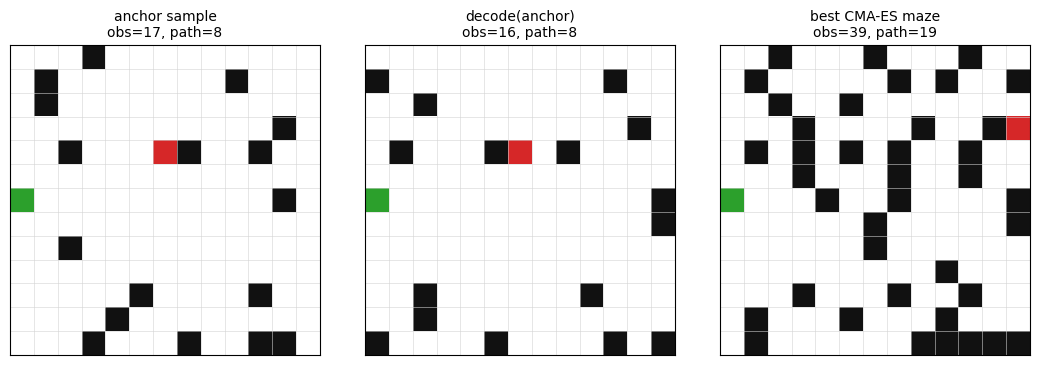

In [6]:
start_sequence = decode_latents(parent_latent[None, :], repair=True)[0]
start_summary = summarize_sequence(start_sequence)
best_summary = summarize_sequence(best_sequence)

print('Best CMA-ES notebook score =', best_score)
print('Start decoded summary =', start_summary)
print('Best decoded summary =', best_summary)

plot_sequence_gallery(
    [parent_sequence, start_sequence, best_sequence],
    [
        f"anchor sample\nobs={summarize_sequence(parent_sequence)['obstacles']}, path={summarize_sequence(parent_sequence)['path_length']}",
        f"decode(anchor)\nobs={start_summary['obstacles']}, path={start_summary['path_length']}",
        f"best CMA-ES maze\nobs={best_summary['obstacles']}, path={best_summary['path_length']}",
    ],
    ncols=3,
    figsize_scale=3.6,
)
plt.show()


## Evaluation Demo: Single Maze Rollout

The cell below runs a trained policy on one maze and renders an animation of the rollout. You can modify the maze that the agent is being evaluated on by editing CUSTOM_EVAL_MAZE_STR and setting USE_CUSTOM_EVAL_MAZE to True.

- full-maze map with the moving agent marker
- optional: define your own maze in the cell (`USE_CUSTOM_EVAL_MAZE = True`)

By default it uses `AGENT_CHECKPOINT_DIR` from the config cell and a prefab from `TEST_LEVEL_NAMES`.

In [7]:
# Single-maze deterministic eval rollout
from pathlib import Path
import importlib

# Pick up latest es/agent_loader.py (Orbax cross-device restore, etc.) without a full kernel restart.
import es.agent_loader as _agent_loader_mod

importlib.reload(_agent_loader_mod)
load_agent = _agent_loader_mod.load_agent
ActorCritic = _agent_loader_mod.ActorCritic
verify_agent_contract = _agent_loader_mod.verify_agent_contract

# Set USE_CUSTOM_EVAL_MAZE=True and edit CUSTOM_EVAL_MAZE_STR to evaluate your own layout.
# Format matches jaxued maze prefabs: '#' wall, '.' empty, 'G' goal,
# agent as '>' (east), 'v' (south), '<' (west), '^' (north). Keep within the env max size (13x13 by default).
USE_CUSTOM_EVAL_MAZE = True
EVAL_LEVEL_NAME = TEST_LEVEL_NAMES[0]  # used when USE_CUSTOM_EVAL_MAZE is False
CUSTOM_EVAL_MAZE_LABEL = 'custom_standard_style'
CUSTOM_EVAL_MAZE_STR = """
.....#>...#..
.###.####.##.
.#...........
.########.###
........#....
######.#####.
....#..#.....
.##...##.####
..#.#..#...#.
#.#.##.###.#.
#.#..#...#...
#.##.###.###.
...#..G#.#...
"""
EVAL_LEVEL_LABEL = CUSTOM_EVAL_MAZE_LABEL if USE_CUSTOM_EVAL_MAZE else EVAL_LEVEL_NAME

EVAL_SEED = 0
EVAL_MAX_STEPS = ROLLOUT_STEPS


def resolve_agent_checkpoint_dirs(root_dir):
    """Return candidate Orbax roots in best-effort order.

    Valid layouts:
    - ``<root>`` is a CheckpointManager dir (numeric step subfolders).
    - ``<root>/<step>/default`` is a single-step leaf (contains ``checkpoint``).
    Do **not** pass ``<root>/<step>`` alone — Orbax has no steps there.
    """
    root = Path(root_dir)
    candidates = []

    if (root / 'checkpoint').exists():
        candidates.append(root)

    step_children = []
    for child in root.iterdir():
        if child.is_dir() and child.name.isdigit() and (child / 'default' / 'checkpoint').exists():
            step_children.append((int(child.name), child))
    if step_children:
        step_children.sort(key=lambda x: x[0], reverse=True)
        candidates.append(root)
        for _, child in step_children:
            candidates.append(child / 'default')

    if (root / 'default' / 'checkpoint').exists():
        candidates.append(root / 'default')

    # De-duplicate while preserving order.
    unique = []
    seen = set()
    for c in candidates:
        c = c.resolve()
        if str(c) not in seen:
            seen.add(str(c))
            unique.append(c)

    # Final fallback to provided path.
    if not unique:
        unique = [root]

    return unique


def policy_action_deterministic(network, params, obs, done, hidden):
    done_batch = jnp.asarray([done], dtype=jnp.bool_)
    model_input = jax.tree_util.tree_map(lambda a: a[None, ...], (obs, done_batch))
    hidden, pi, value = network.apply({'params': params}, model_input, hidden)
    action = int(jnp.argmax(pi.logits[0, 0]))
    return action, hidden, float(value[0, 0])


agent_params = None
network = None
last_error = None
for candidate_dir in resolve_agent_checkpoint_dirs(AGENT_CHECKPOINT_DIR):
    try:
        print('Trying checkpoint dir:', candidate_dir)
        agent_params, network = load_agent(str(candidate_dir), action_dim=7)
        print('Loaded checkpoint from:', candidate_dir)
        break
    except Exception as exc:
        last_error = exc
        print(f'  -> failed: {type(exc).__name__}: {exc}')

if agent_params is None or network is None:
    raise RuntimeError(
        f'Could not load agent checkpoint from AGENT_CHECKPOINT_DIR={AGENT_CHECKPOINT_DIR}. '
        f'Last error: {last_error!r}'
    )

verify_agent_contract(agent_params, network)

env = Maze(agent_view_size=5, normalize_obs=True)
params = env.default_params.replace(max_steps_in_episode=int(EVAL_MAX_STEPS))

if USE_CUSTOM_EVAL_MAZE:
    level = Level.from_str(CUSTOM_EVAL_MAZE_STR.strip())
else:
    level = Level.from_str(prefabs[EVAL_LEVEL_NAME])
rng = jax.random.PRNGKey(EVAL_SEED)
rng, reset_rng = jax.random.split(rng)
obs, state = env.reset_to_level(reset_rng, level, params)

hidden = ActorCritic.initialize_carry((1,))
done = False
total_reward = 0.0
goal_reached = False

positions = [np.asarray(state.agent_pos, dtype=np.int32)]
ego_frames = [np.asarray(obs.image)]
actions = []
values = []

for _ in range(EVAL_MAX_STEPS):
    action, hidden, value_est = policy_action_deterministic(network, agent_params, obs, done, hidden)
    rng, step_rng = jax.random.split(rng)
    obs, state, reward, done, _ = env.step(step_rng, state, action, params)

    reward = float(reward)
    done = bool(done)

    actions.append(action)
    values.append(value_est)
    total_reward += reward
    if reward > 0.0:
        goal_reached = True

    positions.append(np.asarray(state.agent_pos, dtype=np.int32))
    ego_frames.append(np.asarray(obs.image))

    if done:
        break

steps_taken = len(actions)
action_names = ['left', 'right', 'forward', 'pickup', 'drop', 'toggle', 'done']
action_trace = [action_names[a] for a in actions]

print(f'Level: {EVAL_LEVEL_LABEL}')
print(f'Steps taken: {steps_taken}/{EVAL_MAX_STEPS}')
print(f'Total reward: {total_reward:.4f}')
print(f'Goal reached: {goal_reached}')
print('Action trace (first 30):', action_trace[:30])

# --- Animated rollout: full-maze movement ---
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display

base_grid = level_to_grid(level)
xy_all = np.asarray(positions, dtype=np.float32)

# Keep animation responsive by capping frame count.
max_frames = 220
frame_stride = max(1, int(np.ceil(len(xy_all) / max_frames)))
frame_ids = list(range(0, len(xy_all), frame_stride))
if frame_ids[-1] != len(xy_all) - 1:
    frame_ids.append(len(xy_all) - 1)
xy = xy_all[frame_ids]

fig, ax = plt.subplots(1, 1, figsize=(6.4, 6.4))
plot_grid(ax, base_grid, title=f'{EVAL_LEVEL_LABEL}: rollout')

trail_line, = ax.plot([], [], color='tab:blue', linewidth=2.0, alpha=0.9)
agent_dot = ax.scatter([], [], color='deepskyblue', edgecolor='black', s=90, zorder=5)
start_dot = ax.scatter(xy[0, 0], xy[0, 1], color='gold', edgecolor='black', s=80, zorder=6, label='start')
ax.legend(loc='upper right', fontsize=8)
status_text = ax.text(
    0.02,
    1.02,
    '',
    transform=ax.transAxes,
    ha='left',
    va='bottom',
    fontsize=10,
)


def _anim_init():
    trail_line.set_data([], [])
    agent_dot.set_offsets(np.array([[xy[0, 0], xy[0, 1]]]))
    status_text.set_text(f't=0/{steps_taken}')
    return trail_line, agent_dot, status_text


def _anim_update(i):
    trail_line.set_data(xy[: i + 1, 0], xy[: i + 1, 1])
    agent_dot.set_offsets(np.array([[xy[i, 0], xy[i, 1]]]))
    t_idx = frame_ids[i]
    status_text.set_text(f't={t_idx}/{steps_taken}')
    return trail_line, agent_dot, status_text


anim = FuncAnimation(
    fig,
    _anim_update,
    init_func=_anim_init,
    frames=len(xy),
    interval=90,
    blit=False,
    repeat=False,
)

plt.close(fig)
display(HTML(anim.to_jshtml()))


Trying checkpoint dir: /Users/khyledhanani/Documents/openend/superintelligence/notebooks/assets/models
Loading agent checkpoint from /Users/khyledhanani/Documents/openend/superintelligence/notebooks/assets/models (step=119)
Orbax: checkpoint was saved on a different device layout than this process (e.g. CUDA while JAX only sees CPU). Retrying restore with local-device sharding…
Loaded checkpoint from: /Users/khyledhanani/Documents/openend/superintelligence/notebooks/assets/models
Agent contract test PASSED: obs(5,5,3) -> 7 actions, value shape=(1, 1)
Level: custom_standard_style
Steps taken: 194/250
Total reward: 0.3016
Goal reached: True
Action trace (first 30): ['left', 'left', 'left', 'left', 'forward', 'forward', 'forward', 'left', 'left', 'left', 'forward', 'forward', 'left', 'forward', 'forward', 'forward', 'left', 'left', 'forward', 'forward', 'forward', 'left', 'forward', 'forward', 'left', 'forward', 'forward', 'forward', 'left', 'left']
